In [1]:
import torch
import numpy as np
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.objects.normalizer import Normalizer
from sbi_particle_physics.managers.plotter import Plotter
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH, REAL_DATA
from sbi_particle_physics.managers.real_data import RealData
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.objects.imperfections import Imperfections

In [2]:
device = "cpu" # this small test works on cpu
n_points = 5
n_samples = 5
model = Model(device, n_points)

model.set_prior_basic([3], [5])
model.set_simulator(stride=2, pre_N=2, preruns=2, use_imperfections=True, acceptance_coeffs_path=ACCEPTANCE_COEFFS_PATH)

raw_data, raw_parameters = model.simulate_raw_data(n_samples=n_samples, n_points=n_points)
model.set_normalizer_with_data(raw_data=raw_data)
model.build_default()
data = model.normalizer.normalize_data(raw_data)
parameters = model.normalizer.normalize_parameters(raw_parameters)
model.append_data(data, parameters)
model.train(max_num_epochs=2, stop_after_epochs=1)
print("All done")

print("normalized stats", data.mean(dim=(0,1)), data.std(dim=(0,1)))

Loading acceptance coefficients from /home/hep/nrc25/sbi-particle-physics/imperfections/2017_nominal_B0_highq2.dat


Simulating samples:   0%|          | 0/5 [00:00<?, ?it/s]

/home/hep/nrc25/miniconda3/envs/mlhep/lib/python3.12/site-packages/eos/signal_pdf.py:71: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  log_proposal = pypmc.density.gauss.LocalGauss(sigma)


Pre-runs:   0%|          | 0/2 [00:00<?, ?it/s]

Markov chain self adaptation failed; trying diagonalization
Diagonalization failed
Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded


...

max eps 0.3139042556285858, mean eps 0.2882925868034363, median eps 0.28853699564933777, min eps 0.25465822219848633
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 5 out of 30 events (16.7%)


Pre-runs:   0%|          | 0/2 [00:00<?, ?it/s]

Markov chain self adaptation failed; trying diagonalization
Diagonalization failed
Markov chain self adaptation failed; trying diagonalization
Diagonalization succeeded


Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.25190863013267517, mean eps 0.19359570741653442, median eps 0.19251318275928497, min eps 0.10516583174467087
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 4 out of 30 events (13.3%)
 Training neural network. Epochs trained: 3All done
normalized stats tensor([ 9.5367e-09, -9.5367e-09,  3.8147e-08,  0.0000e+00, -1.4305e-08,
         4.9591e-07]) tensor([1.0206, 1.0206, 1.0206, 1.0206, 1.0206, 1.0206])


In [3]:
print("Raw data")
print(raw_data.shape)
print(raw_data[0,:10])
unique_points, counts = torch.unique(
    raw_data[0],
    dim=0,
    return_counts=True
)
print("#unique points", unique_points.shape[0])

print("\nRaw parameters")
print(raw_parameters.shape)
print(raw_parameters[:10])

Raw data
torch.Size([5, 5, 5])
tensor([[ 2.6190,  0.0284, -0.4894,  0.2043,  5.2775],
        [ 4.4759, -0.2803, -0.7138, -0.0292,  5.2856],
        [ 2.0384, -0.7434, -0.7141, -1.5426,  5.3992],
        [ 5.0170, -0.5330, -0.8883,  0.1161,  5.2746],
        [ 5.1342, -0.5502, -1.0000,  0.3725,  5.2776]])
#unique points 5

Raw parameters
torch.Size([5, 1])
tensor([[3.7924],
        [4.5224],
        [3.7593],
        [3.0868],
        [4.2371]])


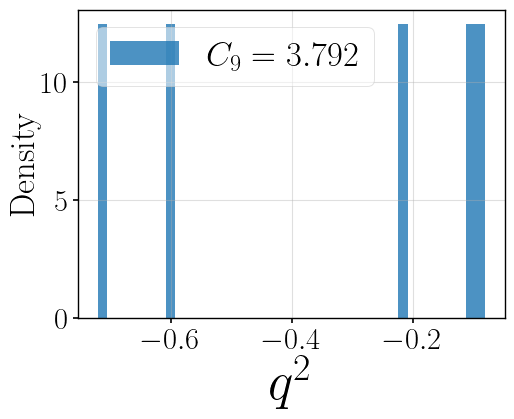

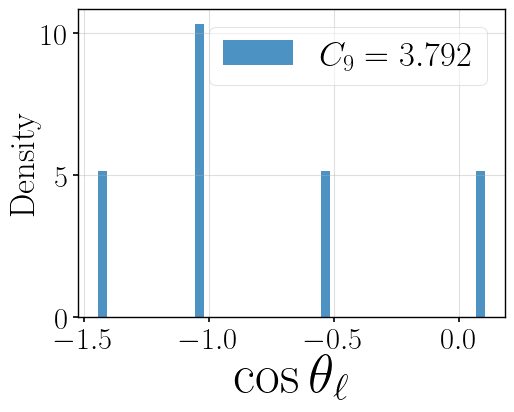

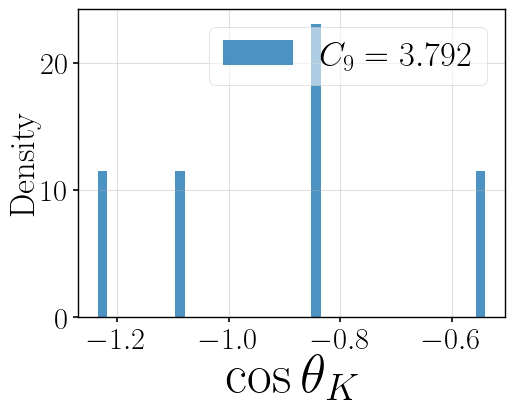

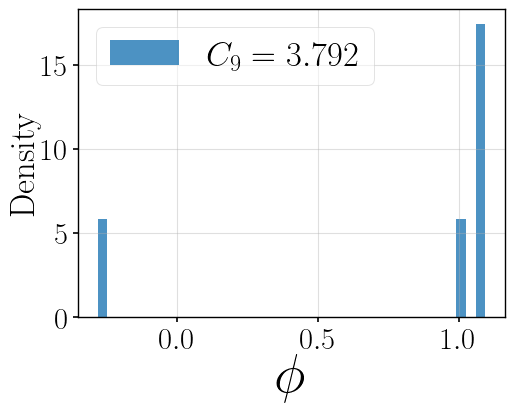

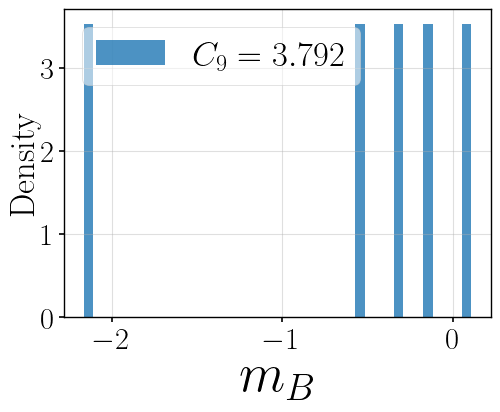

In [4]:
Plotter.plot_a_sample(data[0], parameters[0])

In [5]:
# Check whats the shape of the acceptance function
N = 10000000
u = torch.rand(N, 5, device=device)
u[:, 0] = 1.1 + (6.0 - 1.1) * u[:, 0] # [1.1, 6]
u[:, 1] = -1.0 + 2.0 * u[:, 1] # [-1, 1]
u[:, 2] = -1.0 + 2.0 * u[:, 2] # [-1, 1]
u[:, 3] = -np.pi + 2 * np.pi * u[:, 3] # [-π, π]
u[:, 4] = 5.0 + 0.1 * u[:, 4] # [5.0, 5.1]

v = model.simulator.imperfections._apply_acceptance(u)
print(f"v shape {v.shape}")

max eps 2.121279001235962, mean eps 0.23464742302894592, median eps 0.2522723078727722, min eps -0.08745841681957245
eps < 0: 0.0%, eps > 1: 0.0%
v shape torch.Size([2343318, 5])


In [6]:
datasets = ImperfectionsDiagnostics.get_datasets(model, n_points=50)

Simulating samples:   0%|          | 0/1 [00:00<?, ?it/s]

Pre-runs:   0%|          | 0/2 [00:00<?, ?it/s]

Markov chain self adaptation failed; trying diagonalization
Diagonalization failed
Markov chain self adaptation failed; trying diagonalization
Diagonalization failed


Main run:   0%|          | 0/100 [00:00<?, ?it/s]

max eps 0.3434106409549713, mean eps 0.28475895524024963, median eps 0.28519219160079956, min eps 0.2055043876171112
eps < 0: 0.0%, eps > 1: 0.0%
max eps 0.3434106409549713, mean eps 0.28475895524024963, median eps 0.28519219160079956, min eps 0.2055043876171112
eps < 0: 0.0%, eps > 1: 0.0%
after applying acceptance, kept 16 out of 50 events (32.0%)


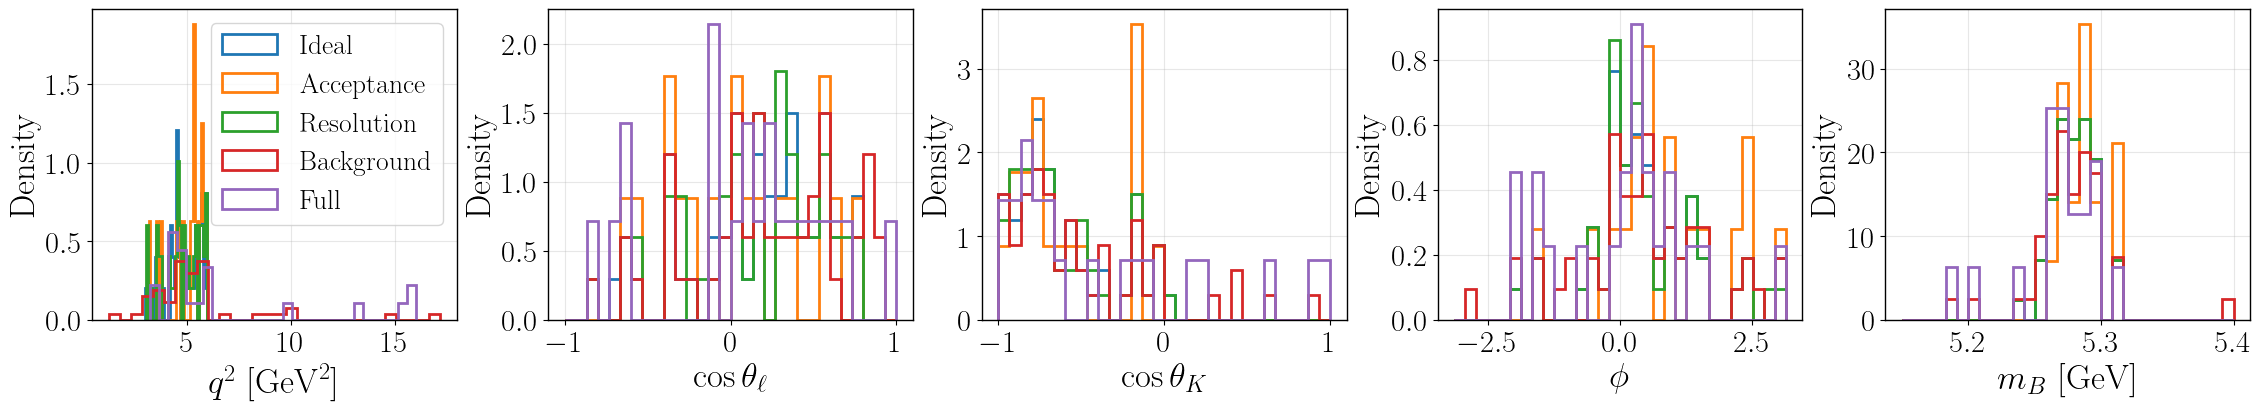

In [7]:
ImperfectionsDiagnostics.compare_datasets(datasets)


In [8]:
ImperfectionsDiagnostics.chi2_test(datasets["Full"], datasets["Ideal"], bins=40)

$q^2\ [\mathrm{GeV}^2]$ : chi2/ndof = 15.18/39, p = 1.000
$\cos\theta_\ell$ : chi2/ndof = 22.84/39, p = 0.982
$\cos\theta_K$ : chi2/ndof = 26.26/39, p = 0.941
$\phi$ : chi2/ndof = 18.23/39, p = 0.998
$m_B\ [\mathrm{GeV}]$ : chi2/ndof = 10.54/39, p = 1.000


In [9]:
background = model.simulator.imperfections._sample_background_events(n=1000000)

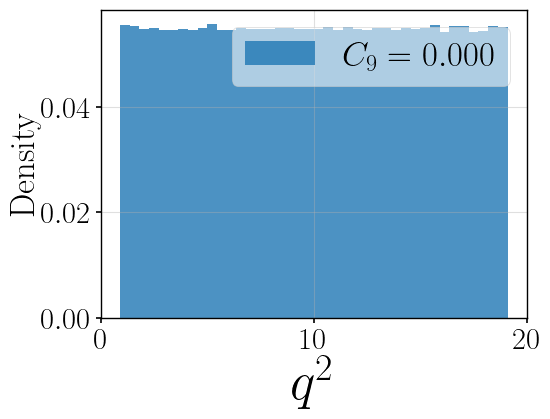

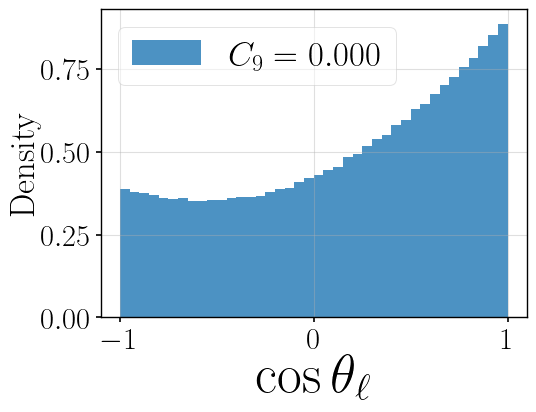

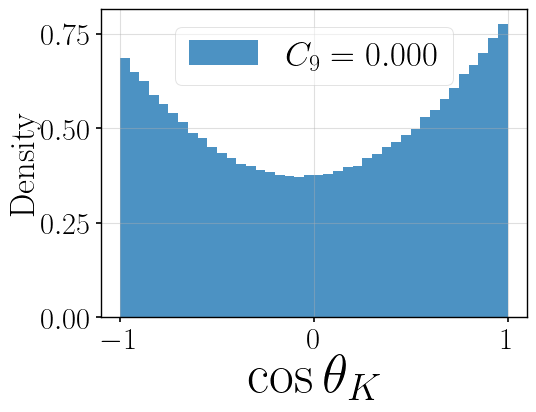

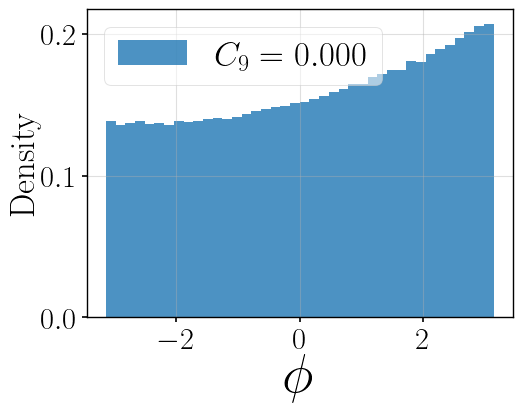

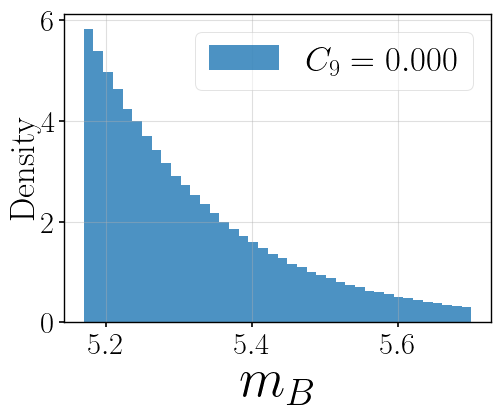

In [10]:
Plotter.plot_a_sample(background, torch.as_tensor([0], device=device))